In [ ]:
import scanpy as sc
import os
import numpy as np
import pandas as pd


# 1. Path to your .h5ad file
FILE_PATH = "GSM6061702_GSM6061683.h5ad"  

# --- 1. Load and Light Preprocessing ---
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Could not find {FILE_PATH}")

adata = sc.read_h5ad(FILE_PATH)

In [29]:
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata)

# --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"
npca = 50
cluster_key = f'leiden_{my_res}' # Renamed key to reflect global clustering


# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (final_adata.obsm['X_pca'])
print(f"Computing nearest neighbors (k={n_neighbors}) and UMAP (n_dims={ndim})...")
sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep = "X_pca", n_pcs=npca) # Stored in neighboars
sc.tl.umap(adata, n_components=ndim, maxiter=500)

sc.tl.leiden(
    adata,
    flavor=algo_cluster,
    n_iterations=2, # Use n_iterations=2 as in the previous code
    resolution=my_res,
    key_added=cluster_key,
)


Computing nearest neighbors (k=15) and UMAP (n_dims=2)...


In [30]:
adata

AnnData object with n_obs × n_vars = 7489 × 17238
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle', 'leiden_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_1.0'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

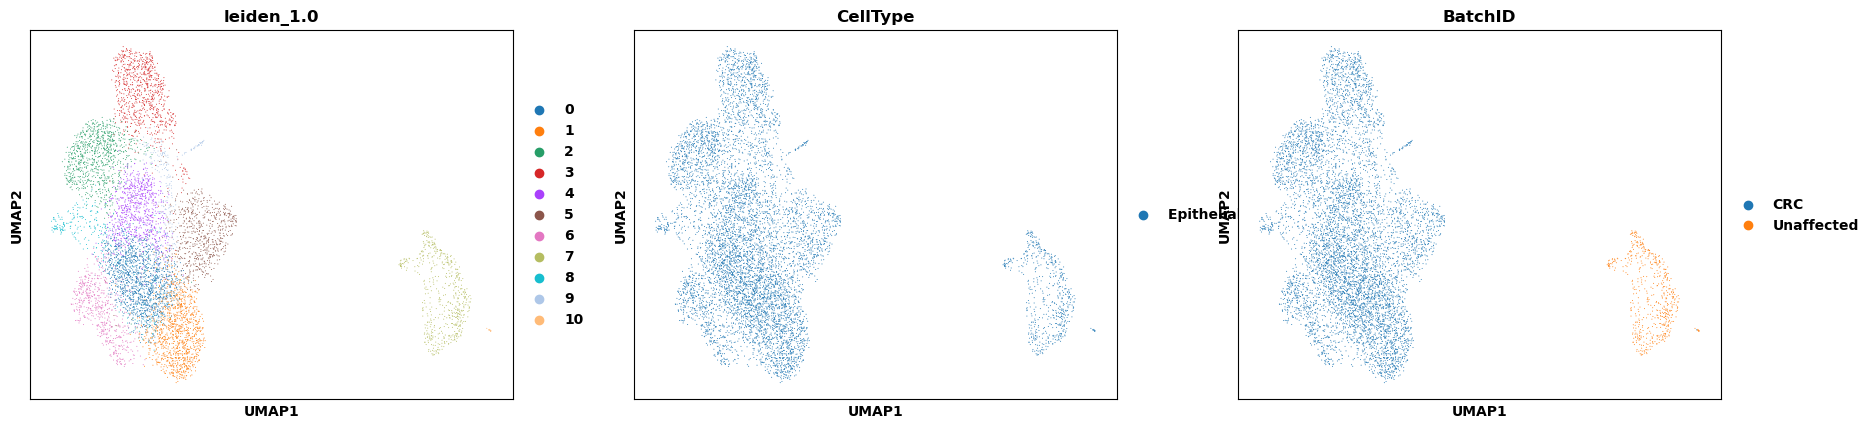

In [32]:
sc.pl.umap(
    adata,
    color=[cluster_key,"CellType", "BatchID"],
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [76]:
def sc_genestat(adata, obs_label, label):
    """
    Compute stats for LINEAR normalized data (no log1p).
    """
    idx = adata.obs[obs_label] == label
    X = adata[idx].X
    if hasattr(X, "toarray"): X = X.toarray()
    
    # 1. No expm1 needed! Work directly on the normalized counts
    u = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    
    # 2. CV calculation (Standard Linear CV)
    cv = np.divide(std, u + 1e-9, out=np.zeros_like(u))
    
    # 3. Dropout (Zeros in normalized data)
    dropr = np.mean(X == 0, axis=0)
    
    # 4. Return the 3D coordinates for the spline (Log-scaling for visualization)
    return pd.DataFrame({
        'lgu': np.log1p(u),    # log1p(mean)
        'lgcv': np.log1p(cv),  # log1p(cv)
        'dropout': dropr 
    }, index=adata.var_names)

In [ ]:
# Function result
df_stats = sc_genestat(adata, "BatchID", "CRC")
func_lgu = df_stats.loc["NOC2L", "lgu"]

# Manual Check: CALCULATE LOG OF MEAN correctly
subset_x = adata[adata.obs["BatchID"] == "CRC", "NOC2L"].X
if hasattr(subset_x, "toarray"): subset_x = subset_x.toarray()

manual_u = np.mean(subset_x)
# Step 3: Log it for the plot
manual_lgu_correct = np.log1p(manual_u)

print(f"Function Log-Mean: {func_lgu:.6f}")
print(f"Correct Manual Log-Mean: {manual_lgu_correct:.6f}")

Function Log-Mean: 0.038355
Correct Manual Log-Mean: 0.038355


In [89]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.interpolate import BSpline
from scipy.stats import zscore, norm
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import diags
import matplotlib.pyplot as plt

# --- CORE FUNCTIONS ---

def robust_lsq_solve(A, y, beta=0.5):
    """Solves Ax = y using Iteratively Reweighted Least Squares."""
    u, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    if beta > 0:
        alpha = 0.5 * beta / (1 - beta)
        for _ in range(3):
            res = A @ u - y
            err = res**2
            weights = np.exp(-(alpha / (np.mean(err) + 1e-9)) * err)
            W = diags(weights)
            try:
                lhs = A.T @ W @ A
                rhs = A.T @ W @ y
                u = np.linalg.solve(lhs, rhs)
            except np.linalg.LinAlgError:
                break
    return u
    
def sc_splinefit(adata, obs_label, label, n_pieces=15, beta=0.75):
    """
    Python implementation of MATLAB sc_splinefit.
    Parametric fitting using cumulative distance (arc length).
    """
    # 1. Get stats (using the linear-normalized logic we validated)
    stats = sc_genestat(adata, obs_label, label)
    
    # 2. MATLAB sorts the data by [lgu, lgcv, dropr] before cumsum
    # This is critical for the 's' parameter to make sense
    stats = stats.sort_values(['lgu', 'lgcv', 'dropout']).reset_index()
    
    lgu = stats['lgu'].values
    lgcv = stats['lgcv'].values
    dropr = stats['dropout'].values
    genes = stats['index'].values # original gene names
    
    xyz = np.vstack([lgu, lgcv, dropr]).T
    
    # 3. Compute 's' (Parametric distance / Arc Length)
    # s = cumsum([0; sqrt(diff(lgu).^2 + diff(lgcv).^2 + diff(dropr).^2)])
    diffs = np.diff(xyz, axis=0)
    dists = np.sqrt(np.sum(diffs**2, axis=1))
    s = np.concatenate([[0], np.cumsum(dists)])
    
    # 4. Setup B-Spline Basis on 's'
    breaks = np.linspace(s.min(), s.max(), n_pieces + 1)
    k = 3 # Cubic
    knots = np.concatenate([[breaks[0]]*k, breaks, [breaks[-1]]*k])
    n_basis = len(breaks) + k - 1
    
    A = np.zeros((len(s), n_basis))
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1.0
        A[:, i] = BSpline(knots, coeffs, k)(s)

    # 5. Robust Fit (IRLS) for all three dimensions
    # MATLAB fits the whole xyz' matrix to s
    coef_lgu = robust_lsq_solve(A, lgu, beta=beta)
    coef_cv = robust_lsq_solve(A, lgcv, beta=beta)
    coef_dr = robust_lsq_solve(A, dropr, beta=beta)
    
    # 6. Evaluate the fit (xyz1 in MATLAB)
    xyz1 = np.vstack([A @ coef_lgu, A @ coef_cv, A @ coef_dr]).T
    
    # 7. Nearest Neighbor search (dsearchn in MATLAB)
    nn = NearestNeighbors(n_neighbors=1).fit(xyz1)
    dist, near_idx = nn.kneighbors(xyz)
    dist = dist.flatten()
    near_idx = near_idx.flatten()
    
    # 8. Apply MATLAB's distance weighting logic
    # d(x > max(fitmeanv)) = d ./ 100; etc.
    fitmeanv = xyz1[:, 0]
    x = xyz[:, 0]
    y = xyz[:, 1]
    
    final_dist = dist.copy()
    final_dist[x > np.max(fitmeanv)] /= 100
    final_dist[x < np.min(fitmeanv)] /= 10
    
    # d((y-xyz1(:, 2))<0) = d./100 (if below the CV curve, reduce distance)
    # y is the data lgcv, xyz1[:,1] is the fitted lgcv
    residual_cv = y - xyz1[near_idx, 1]
    final_dist[residual_cv < 0] /= 100
    
    T = pd.DataFrame({
        'genes': genes,
        'lgu': lgu,
        'lgcv': lgcv,
        'dropr': dropr,
        'dist': final_dist,
        'near_idx': near_idx
    })
    
    return T, xyz, xyz1

In [ ]:
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="CRC", n_pieces=15, beta=0.75)

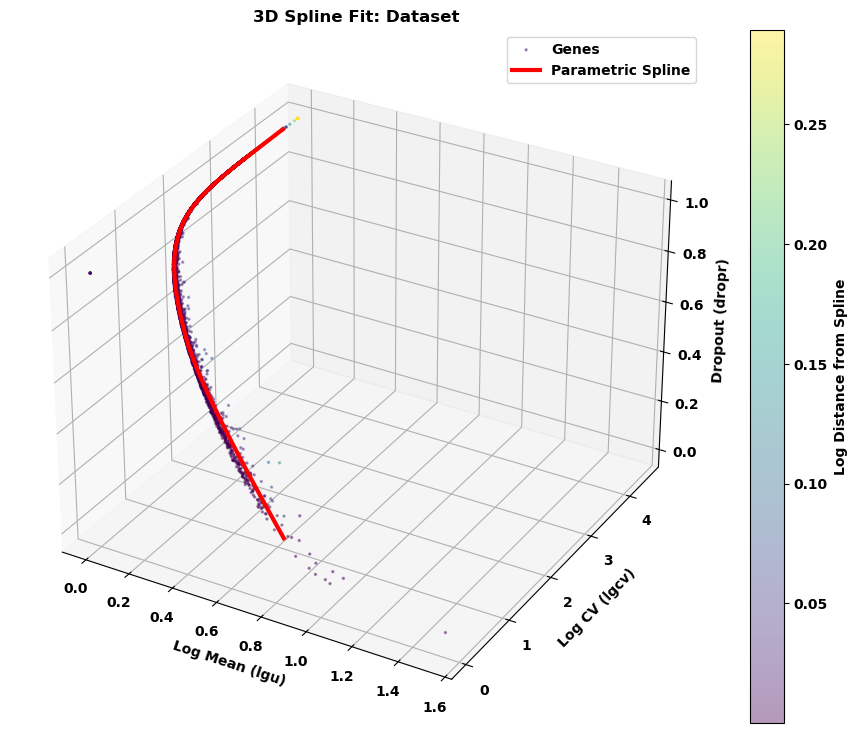

In [93]:
from mpl_toolkits.mplot3d import Axes3D

def plot_spline(T, xyz, xyz1, label="Dataset"):
    """
    Visualizes the 3D gene cloud and the parametric spline fit.
    Colors the genes by their distance (residual) from the spline.
    """
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Scatter the genes
    # We use a log-transform on distance for the color scale to highlight outliers
    scatter = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                         c=np.log1p(T['dist']), cmap='viridis', 
                         s=2, alpha=0.4, label='Genes')

    # 2. Plot the fitted spline curve
    ax.plot(xyz1[:, 0], xyz1[:, 1], xyz1[:, 2], 
            color='red', linewidth=3, label='Parametric Spline', zorder=10)

    # 3. Labeling
    ax.set_title(f"3D Spline Fit: {label}")
    ax.set_xlabel('Log Mean (lgu)')
    ax.set_ylabel('Log CV (lgcv)')
    ax.set_zlabel('Dropout (dropr)')
    
    fig.colorbar(scatter, ax=ax, label='Log Distance from Spline')
    ax.legend()
    plt.show()


plot_spline(crc_spline, crc_xyz, crx_xyz1)

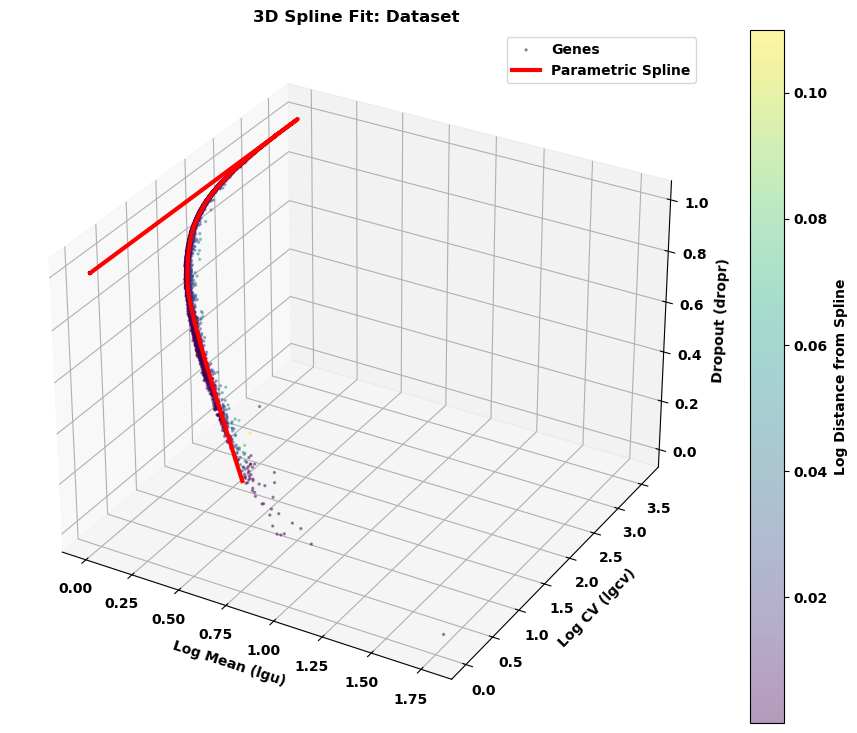

In [104]:
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="Unaffected", n_pieces=15, beta=0.75)
plot_spline(crc_spline, crc_xyz, crx_xyz1)

In [105]:
def sc_splinedv(adata1, adata2, obs_label, cond_1, cond_2, fname=None, plotit=False, beta=0.75):
    # 1. Fit splines
    T1, xyz1, xyzp1 = sc_splinefit(adata1, obs_label, cond_1, beta=beta)
    T2, xyz2, xyzp2 = sc_splinefit(adata2, obs_label, cond_2, beta=beta)

    # 2. Intersection & Sorting (Equivalent to intersect 'stable' + sortrows 'genes')
    T1 = T1.set_index('genes')
    T2 = T2.set_index('genes')
    common_genes = T1.index.intersection(T2.index)
    
    T1 = T1.loc[common_genes].reset_index()
    T2 = T2.loc[common_genes].reset_index()
    
    # Re-extract xyz for aligned genes
    xyz1_aligned = np.vstack([T1.lgu, T1.lgcv, T1.dropr]).T
    xyz2_aligned = np.vstack([T2.lgu, T2.lgcv, T2.dropr]).T

    # 3. Vector Residuals: v = xyz - xyzp(nearidx)
    v1 = xyz1_aligned - xyzp1[T1['near_idx'].values]
    v2 = xyz2_aligned - xyzp2[T2['near_idx'].values]

    # 4. Differential Distance Logic
    dist_diff = np.linalg.norm(v1 - v2, axis=1)
    dist_sign = np.sign(T1['dist'].values - T2['dist'].values)
    
    # Standardize and compute P-value
    ddz = zscore(dist_diff)
    pval = 1 - norm.cdf(ddz)

    # 5. Merge into Final Table
    Tdv = pd.concat([
        T1.drop(columns=['near_idx']).add_suffix('_1'), 
        T2.drop(columns=['near_idx', 'genes']).add_suffix('_2'),
        pd.DataFrame({'dist_diff': dist_diff, 'dist_sign': dist_sign, 'pval': pval})
    ], axis=1).rename(columns={'genes_1': 'gene'})

    # 6. Boundary Protection (MATLAB's idxx logic)
    # Zero out differences for genes mapped to the very start or end of the spline
    max_idx1, max_idx2 = T1['near_idx'].max(), T2['near_idx'].max()
    idxx = (T1['near_idx'] <= 1) | (T2['near_idx'] <= 1) | \
           (T1['near_idx'] == max_idx1) | (T2['near_idx'] == max_idx2)
    Tdv.loc[idxx, 'dist_diff'] = 0

    Tdv = Tdv.sort_values("dist_diff", ascending=False)

    if fname:
        Tdv.to_csv(f"{fname}_diff_var.csv", index=False)

    if plotit:
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        # Condition 1: Blue spline, Cyan-ish dots
        ax.scatter(xyz1_aligned[:,0], xyz1_aligned[:,1], xyz1_aligned[:,2], s=20, edgecolors='c', facecolors='none', alpha=0.3, label=f'{cond_1} Stats')
        ax.plot(xyzp1[:,0], xyzp1[:,1], xyzp1[:,2], 'b-', linewidth=2, label=f'{cond_1} Spline')
        # Condition 2: Red spline, Green-ish dots
        ax.scatter(xyz2_aligned[:,0], xyz2_aligned[:,1], xyz2_aligned[:,2], s=20, edgecolors='g', facecolors='none', alpha=0.3, label=f'{cond_2} Stats')
        ax.plot(xyzp2[:,0], xyzp2[:,1], xyzp2[:,2], 'r-', linewidth=2, label=f'{cond_2} Spline')
        
        ax.set_title('Comparison of Conditions: Gene Statistics vs. Spline')
        ax.set_xlabel('Log1p Mean'); ax.set_ylabel('Log1p CV'); ax.set_zlabel('Dropout Rate')
        ax.legend(); plt.show()

    return Tdv

def run_splinedv_on_adata(adata, cell_type_col, cell_type, condition_col, cond_1, cond_2, **kwargs):
    """
    Subsets AnnData by cell type and condition, then runs sc_splinedv.
    """
    # Subset by cell type first
    adata_ct = adata[adata.obs[cell_type_col] == cell_type].copy()
    
    # Split by condition
    a1 = adata_ct[adata_ct.obs[condition_col] == cond_1].copy()
    a2 = adata_ct[adata_ct.obs[condition_col] == cond_2].copy()
    
    print(f"Comparing {cond_1} ({a1.n_obs} cells) vs {cond_2} ({a2.n_obs} cells)")

    # Call the differential variability function
    # Note: We pass the specific sub-adata objects and the labels
    return sc_splinedv(a1, a2, condition_col, cond_1, cond_2, **kwargs)

Comparing Unaffected (559 cells) vs CRC (6930 cells)


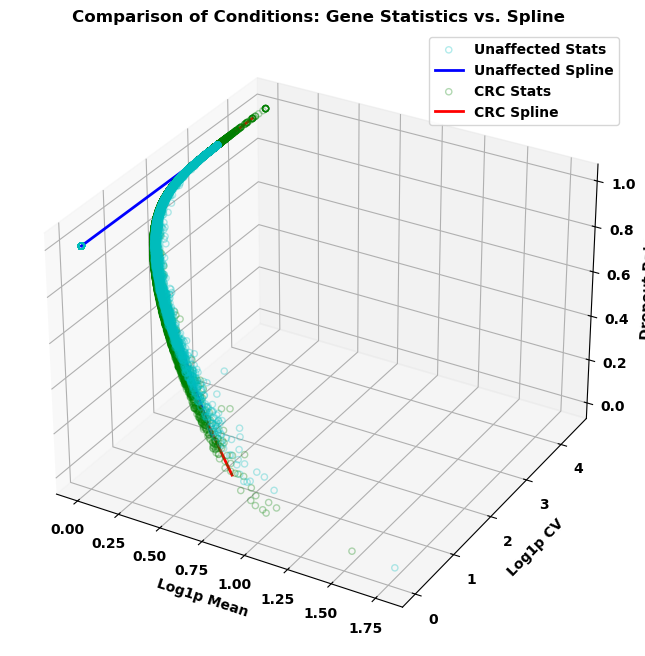

            gene     lgu_1    lgcv_1   dropr_1    dist_1     lgu_2    lgcv_2  \
17078     MS4A12  0.457508  0.734644  0.474061  0.040580  0.000000  0.000000   
13968      CD177  0.080622  1.413581  0.883721  0.007389  0.000000  0.000000   
11632     B3GNT6  0.039229  1.758298  0.946333  0.006946  0.000000  0.000000   
10299  ANKRD20A3  0.026848  1.823313  0.953488  0.002380  0.000000  0.000000   
10152       BMP3  0.025753  1.832336  0.955277  0.001903  0.000000  0.000000   
8910        LDHD  0.018105  2.006618  0.971377  0.000007  0.000000  0.000000   
14088    FAM95B1  0.084234  1.365546  0.874776  0.000038  0.000000  0.000000   
10600      IGHA2  0.029128  1.807332  0.960644  0.000066  0.000000  0.000000   
15359       GRM8  0.136102  1.351741  0.865832  0.049404  0.686168  0.654697   
8125        NKD1  0.014125  2.153190  0.982111  0.000033  0.803505  0.513137   

        dropr_2    dist_2  dist_diff  dist_sign      pval  
17078  1.000000  0.009718   0.991071        1.0  0.000000  

In [106]:
results = run_splinedv_on_adata(
    adata,
    cell_type_col = 'CellType',
    cell_type     = 'Epithelial cells',
    condition_col = 'BatchID',
    cond_1        = 'Unaffected',
    cond_2        = 'CRC',
    fname         = 'results/epithelial_spline', 
    plotit        = True,
    beta          = 0.75
)

# Display top genes where CRC is more variable than Unaffected
print(results.sort_values('dist_diff', ascending=False).head(10))